In [18]:
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from evaluation.test_datasets import FaceRecogntionDataset
from evaluation.open_set_methods.class_prob_models import MonteCarloPredictiveProb
from evaluation.open_set_methods.calibration_methods import Standartization
import torch
from evaluation.open_set_methods.posterior_prob_based import PosteriorProb

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
raw_image_path = "/app/datasets/interpolation.png"
raw_image = cv2.imread(raw_image_path)
result_dataset_path = Path("/app/datasets/interpolation")
loose_crop_path = result_dataset_path / "loose_crop"

In [3]:
# result_dataset_path = Path("/app/datasets/interpolation")
# result_dataset_path.mkdir(exist_ok=True)
# loose_crop_path = result_dataset_path / "loose_crop"
# loose_crop_path.mkdir(exist_ok=True)

# id_to_images = {id: [] for id in range(3)}
# for i in range(3):
#     out_path = result_dataset_path / str(i)
#     out_path.mkdir(exist_ok=True)
#     for j in range(9):
#         crop_image = raw_image[i * 256 : (i + 1) * 256, j * 256 : (j + 1) * 256]
#         id_to_images[i].append(crop_image)
#         cv2.imwrite(str(out_path / (str(j).zfill(4) + ".jpg")), crop_image)
#         cv2.imwrite(
#             str(loose_crop_path / (str(i) + "_" + str(j).zfill(4) + ".jpg")), crop_image
#         )

### Get embeddings

In [4]:
# import insightface
# from insightface.app import FaceAnalysis
# from insightface.data import get_image as ins_get_image

# app = FaceAnalysis(
#     providers=["CUDAExecutionProvider", "CPUExecutionProvider"],
#     root="./data/insightface",
# )
# app.prepare(ctx_id=0, det_size=(256, 256))

In [5]:
# id_to_landmarks = {id: [] for id in range(3)}
# for id in id_to_images:
#     out_path = result_dataset_path / str(id)
#     for j in range(9):
#         # image_path = str(out_path / (str(j).zfill(4)+'.jpg'))
#         # image = cv2.imread(image_path)[:,:,::-1]
#         image = id_to_images[id][j]
#         faces = app.get(image)
#         assert len(faces) == 1, j
#         id_to_landmarks[id].append(faces[0]["kps"])

In [6]:
# # save landmarks
# meta_dir = result_dataset_path / "meta"
# meta_dir.mkdir(exist_ok=True)
# with open(meta_dir / "inter_name_5pts_score.txt", "w") as fd:
#     for id in id_to_landmarks:
#         for j in range(9):
#             name = str(id) + "_" + str(j).zfill(4) + ".jpg"
#             data = [name]
#             for point in id_to_landmarks[id][j]:
#                 point = [str(np.round(x, 3)) for x in point]
#                 data += point
#             data += [str(1.0)]
#             fd.write(" ".join(data) + "\n")
# id_to_landmarks[0][0]

### Create gallery and compute 

In [7]:
# embs = np.load("/app/cache/features/scf_embs_inter.npz")

In [8]:
# load embeddings

id_to_embs = {id: [] for id in range(3)}
id_to_unc = {id: [] for id in range(3)}
embs = np.load("/app/cache/features/scf_2epoch_embs_inter.npz")
for i in range(3):
    for j in range(9):
        id_to_embs[i].append(embs["embs"][i * 9 + j])
        id_to_unc[i].append(embs["unc"][i * 9 + j, 0])

In [9]:
id_to_embs[0][0] @ id_to_embs[0][0]

1.0

In [10]:
def draw_frame(image, color, width):
    rgb_color = (np.array(matplotlib.colors.to_rgb(color)) * 255).astype("uint8")
    print(rgb_color)
    image = np.copy(image)
    image[0:width, :] = rgb_color
    image[-width:, :] = rgb_color
    image[:, 0:width] = rgb_color
    image[:, -width:] = rgb_color
    return image

Extract template feature: 100%|██████████| 1772/1772 [00:00<00:00, 5905.97it/s]


In [26]:
def get_holue_unc(
    test_id,
    gallery_embeddings,
    gallery_unc,
    probe_embs,
    probe_unc,
    gallery_kappa,
    T,
    num_images=9,
):
    standartization = Standartization(
        normalize_kl_by_test=False, log_dir="outputs/inter"
    )
    ## HolUE
    calibration_set = FaceRecogntionDataset("ms1m", "/app/datasets/ms1m_ident")
    holue = MonteCarloPredictiveProb(
        M=0,
        gallery_kappa=gallery_kappa,  # 442.7924, #403.3256,
        gallery_prior="vMF",
        emb_unc_model="vMF",
        kappa_input_scale=1,
        beta=0.5,
        alpha=0.5,
        predict_T=T,
        pred_uncertainty_type="entropy",
        far=0.1,
        calibration_set=calibration_set,
        calibration_embs_name="scf_2epoch",
        calibration_transform=standartization,
    )
    # gallery_embeddings = np.concatenate(
    #     [id_to_embs[test_id][0][np.newaxis, :], id_to_embs[test_id][-1][np.newaxis, :]]
    # )
    # gallery_unc = np.exp(
    #     np.array([id_to_unc[test_id][0], id_to_unc[test_id][-1]])[:, np.newaxis]
    # )
    holue.setup(
        probe_feats=np.array(probe_embs),
        probe_unc=np.exp(probe_unc[:, np.newaxis]),
        gallery_feats=gallery_embeddings,
        gallery_unc=gallery_unc,
        g_unique_ids=np.array([0, num_images + 1]),
        probe_unique_ids=np.arange(0, num_images + 1),
    )
    return holue.predict_uncertainty()

Extract template feature: 100%|██████████| 1772/1772 [00:00<00:00, 6012.52it/s]


Found kappa 1227.051 for far 0.0
Found kappa 872.949 for far 0.0
Found kappa 872.949 for far 0.0
Found kappa 654.102 for far 0.00042637862421830583
Found kappa 654.102 for far 0.00042637862421830583
Found kappa 518.8471 for far 0.00412166003411029
Found kappa 518.8471 for far 0.00412166003411029
Found kappa 435.2549 for far 0.027288231949971573
Found kappa 435.2549 for far 0.027288231949971573
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 351.6628 for far 0.1321773735076748
Found kappa 403.3256 for far 0.04931779420125071
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 371.3962 for far 0.09152927799886298
Found kappa 371.3962 for far 0.09152927799886298
Found kappa 363.8587 for far 0.10602615122228538
Found kappa 363.8587 for far 0.10602615122228538
Found kappa 359.2003 for far 0.1137009664582149
Found kappa_calib 363.8587 for far 0.1
[214  39  40]
[ 31 119 180]

Extract template feature: 100%|██████████| 1772/1772 [00:00<00:00, 5905.10it/s]


Found kappa 1227.051 for far 0.0
Found kappa 872.949 for far 0.0
Found kappa 872.949 for far 0.0
Found kappa 654.102 for far 0.00042637862421830583
Found kappa 654.102 for far 0.00042637862421830583
Found kappa 518.8471 for far 0.00412166003411029
Found kappa 518.8471 for far 0.00412166003411029
Found kappa 435.2549 for far 0.027288231949971573
Found kappa 435.2549 for far 0.027288231949971573
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 351.6628 for far 0.1321773735076748
Found kappa 403.3256 for far 0.04931779420125071
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 371.3962 for far 0.09152927799886298
Found kappa 371.3962 for far 0.09152927799886298
Found kappa 363.8587 for far 0.10602615122228538
Found kappa 363.8587 for far 0.10602615122228538
Found kappa 359.2003 for far 0.1137009664582149
Found kappa_calib 363.8587 for far 0.1
[214  39  40]
[ 31 119 180]

Extract template feature: 100%|██████████| 1772/1772 [00:00<00:00, 6033.48it/s]


Found kappa 1227.051 for far 0.0
Found kappa 872.949 for far 0.0
Found kappa 872.949 for far 0.0
Found kappa 654.102 for far 0.00042637862421830583
Found kappa 654.102 for far 0.00042637862421830583
Found kappa 518.8471 for far 0.00412166003411029
Found kappa 518.8471 for far 0.00412166003411029
Found kappa 435.2549 for far 0.027288231949971573
Found kappa 435.2549 for far 0.027288231949971573
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 351.6628 for far 0.1321773735076748
Found kappa 403.3256 for far 0.04931779420125071
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 383.5921 for far 0.07106310403638431
Found kappa 371.3962 for far 0.09152927799886298
Found kappa 371.3962 for far 0.09152927799886298
Found kappa 363.8587 for far 0.10602615122228538
Found kappa 363.8587 for far 0.10602615122228538
Found kappa 359.2003 for far 0.1137009664582149
Found kappa_calib 363.8587 for far 0.1
[214  39  40]
[ 31 119 180]

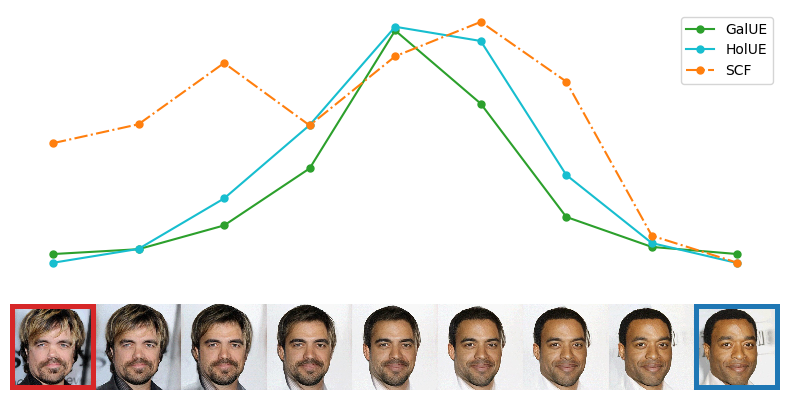

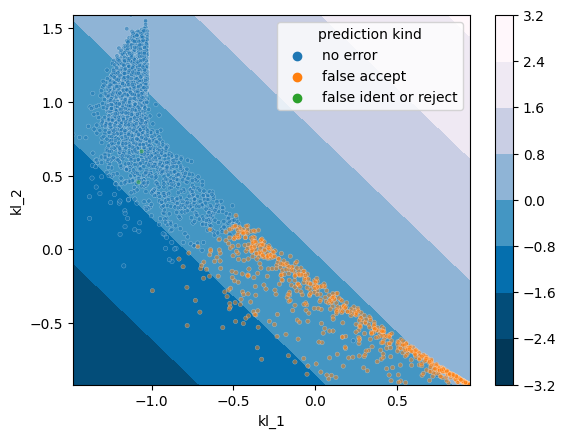

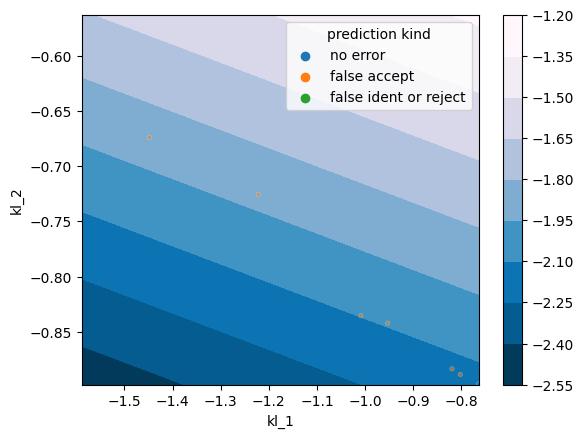

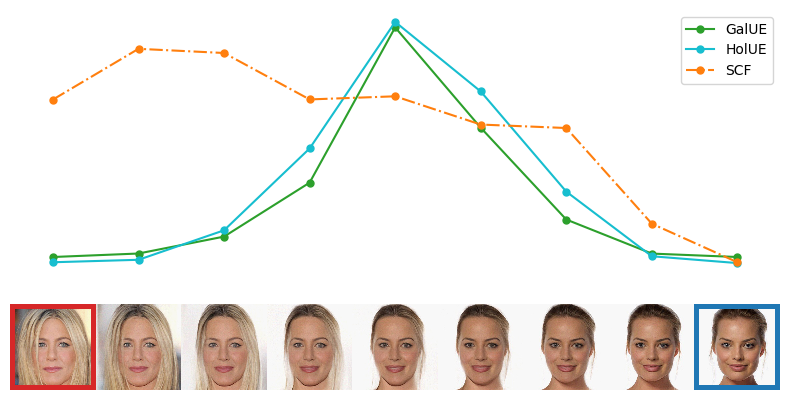

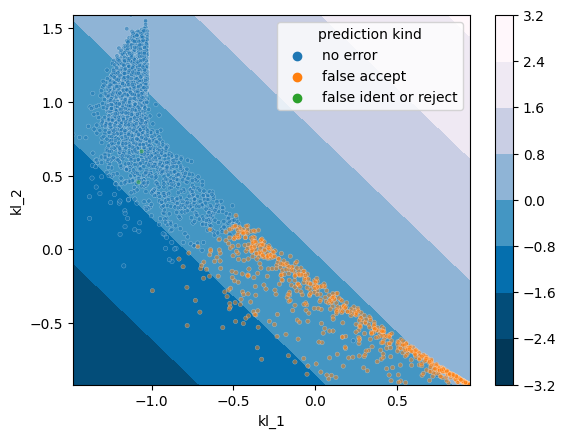

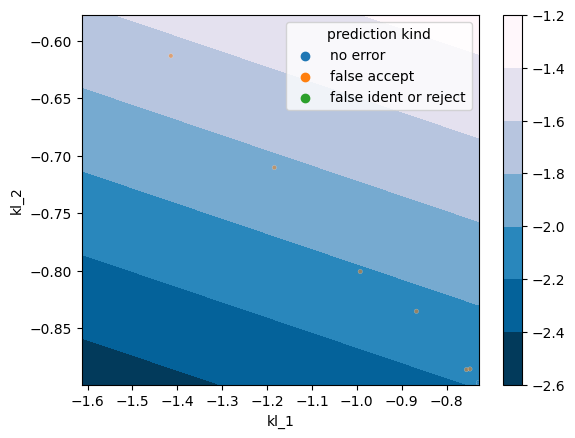

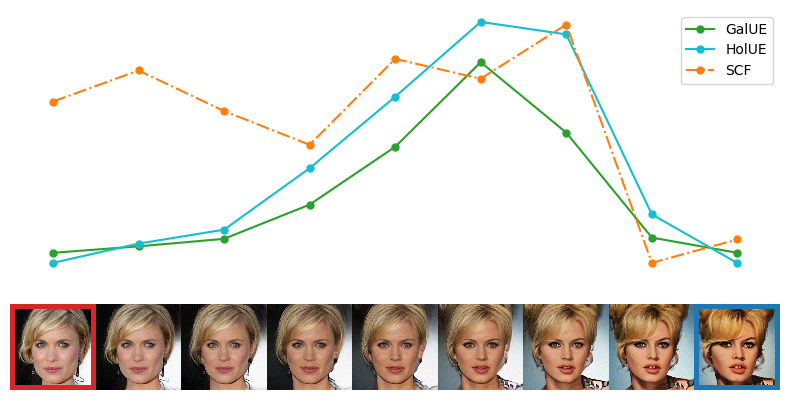

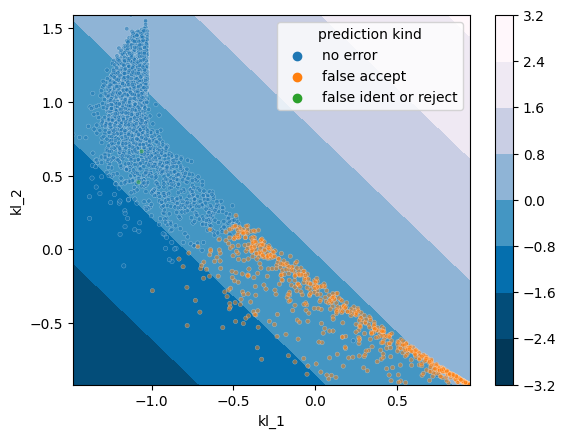

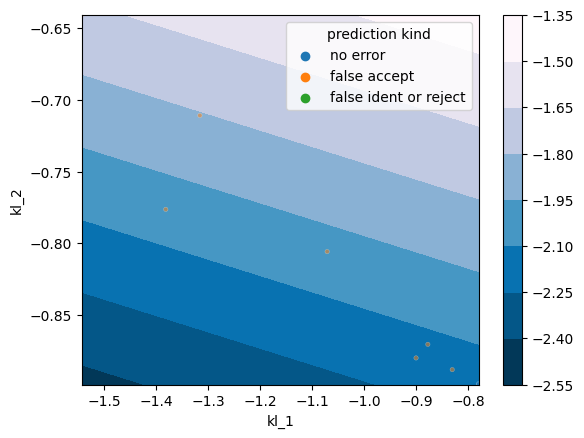

In [70]:
T = 5
gallery_kappa = 25
T_holue = 5
kappa = 25
id_to_color = {0: "black", 1: "green", 2: "cyan"}
ids = [0, 1, 2]
estimator = PosteriorProb(kappa=kappa, beta=0.5, class_model="vMF", K=2)
for test_id in ids:
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5), frameon=False)
    # Remove horizontal space between axes
    fig.subplots_adjust(hspace=0, bottom=0, wspace=0)
    first_gallery_emb = id_to_embs[test_id][0]
    second_gallery_emb = id_to_embs[test_id][-1]
    gallery_embeddings = np.concatenate(
        [first_gallery_emb[np.newaxis, :], second_gallery_emb[np.newaxis, :]]
    )
    probe_embeddings = []
    for j in np.arange(0, 9):
        probe_embeddings.append(id_to_embs[test_id][j])

    probe_embeddings = np.array(probe_embeddings)
    # compute similarity matrix
    similarity_matrix = probe_embeddings @ gallery_embeddings.T

    probabilities = torch.exp(
        estimator.compute_all_class_log_probabilities(
            torch.tensor(similarity_matrix), T=T
        )
    ).numpy()
    unc_holue = get_holue_unc(
        test_id, id_to_embs, id_to_unc, gallery_kappa=gallery_kappa, T=T_holue
    )
    scale = 256
    shift = 256 / 2
    axs[0].plot(
        np.arange(9) * scale + shift,
        (-np.max(probabilities, axis=1) + 1) * scale,
        marker="o",
        markersize=5,
        label=f"GalUE",
        color="tab:green",  # id_to_color[test_id],
    )
    # holue unc
    axs[0].plot(
        np.arange(9) * scale + shift,
        (unc_holue - unc_holue[0]) * scale,
        marker="o",
        markersize=5,
        label=f"HolUE",
        color="tab:cyan",
    )
    data_unc = -np.array(np.exp(id_to_unc[test_id]))
    data_unc = (data_unc - np.min(data_unc)) / (
        (np.max(data_unc) - np.min(data_unc)) * 2
    )
    axs[0].plot(
        np.arange(9) * scale + shift,
        data_unc * scale,
        marker="o",
        markersize=5,
        label=f"SCF",
        color="tab:orange",  # id_to_color[test_id],
        linestyle="dashdot",
    )
    # axs[0].set(xlabel=None)
    axs[0].axis("off")
    # ax2.imshow(np.concatenate(id_to_images[test_id], axis=1), extent=[0, -256 * 9, 0, -256], interpolation="none")
    images = []
    for j in range(9):
        image_path = str(
            loose_crop_path / (str(test_id) + "_" + str(j).zfill(4) + ".jpg")
        )
        images.append(plt.imread(image_path))
    # gallery images outline
    images[0] = draw_frame(images[0], "tab:red", 15)
    images[-1] = draw_frame(images[-1], "tab:blue", 15)
    axs[1].imshow(np.concatenate(images, axis=1), interpolation="none")
    axs[1].axis("off")
    axs[0].legend()
    fig.tight_layout()
    fig.savefig(
        f"/app/paper_assets/images/inter_{test_id}",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0,
    )

### Gaussian noise

In [7]:
# load probe embeddings
nose_iteration_size = 15

id_to_gallery_emb = {id: [] for id in range(3)}
embs = np.load("/app/cache/features/scf_2epoch_embs_inter.npz")
for i in range(3):
    id_to_gallery_emb[i].append(embs["embs"][i * 9 + 0][np.newaxis, :])
    id_to_gallery_emb[i].append(embs["embs"][i * 9 + 8][np.newaxis, :])

id_to_probe_emb = {id: [] for id in range(3)}
id_to_probe_unc = {id: [] for id in range(3)}
embs_probe = np.load("/app/cache/features/scf_2epoch_embs_nose.npz")
for id in range(3):
    for i in range(nose_iteration_size + 1):
        id_to_probe_emb[id].append(
            embs_probe["embs"][id * (nose_iteration_size + 1) + i]
        )
        id_to_probe_unc[id].append(
            embs_probe["unc"][id * (nose_iteration_size + 1) + i, 0]
        )

In [28]:
probe_image_index = 1
nose_dataset_dir = Path("/app/datasets/gaussian_nose")
loose_crop_path = nose_dataset_dir / "loose_crop"

In [24]:
np.array(id_to_probe_unc[test_id]).shape, probe_embeddings.shape

((16,), (15, 512))

Extract template feature: 100%|██████████| 1772/1772 [00:00<00:00, 5908.11it/s]
/tmp/ipykernel_354329/2018515569.py:97: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs_prob[0].set_yticklabels(
Extract template feature: 100%|██████████| 1772/1772 [00:00<00:00, 5790.38it/s]
/tmp/ipykernel_354329/2018515569.py:97: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs_prob[0].set_yticklabels(
Extract template feature: 100%|██████████| 1772/1772 [00:00<00:00, 5918.94it/s]
/tmp/ipykernel_354329/2018515569.py:97: UserWarning: FixedFormatter should only be used together with FixedLocator
  axs_prob[0].set_yticklabels(


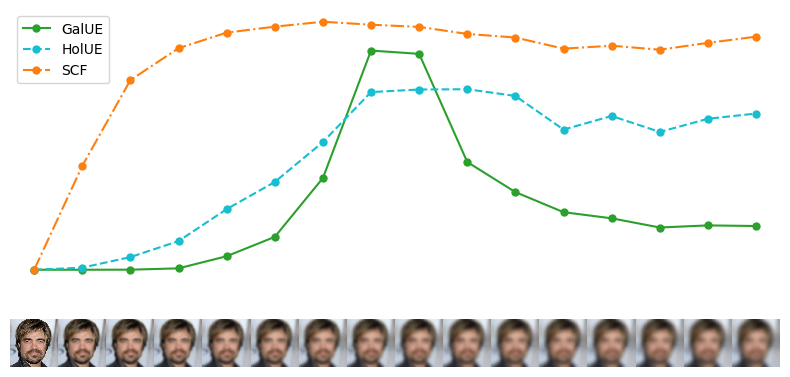

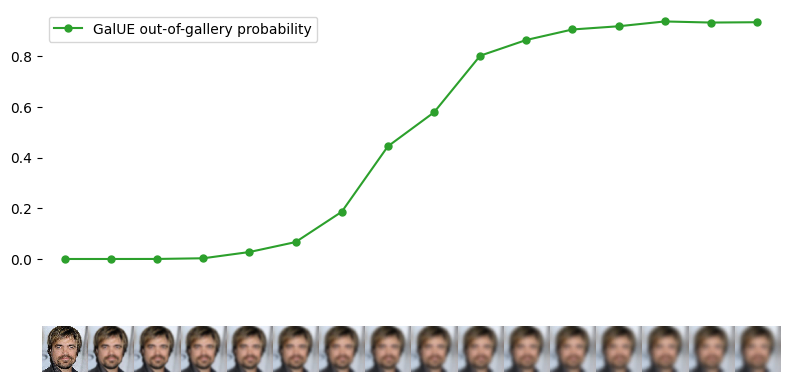

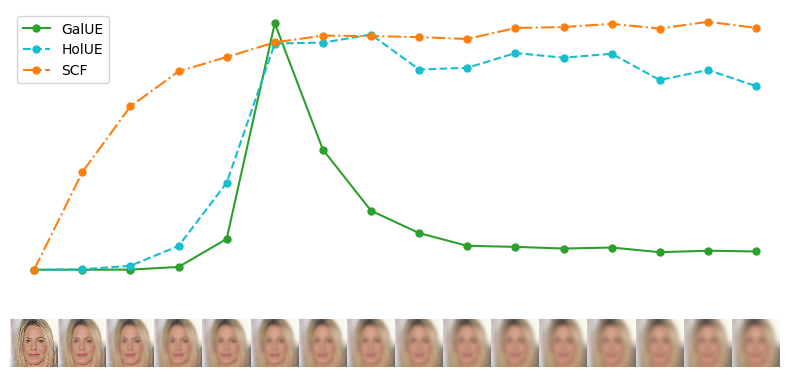

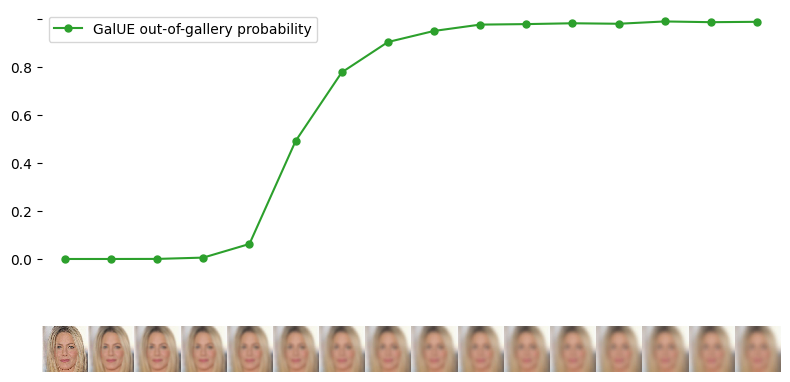

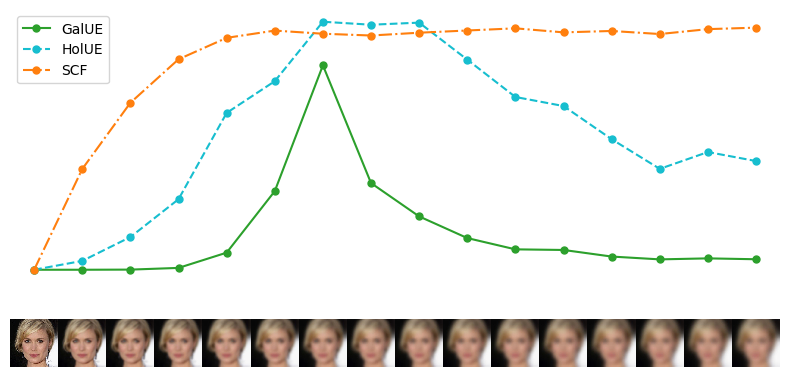

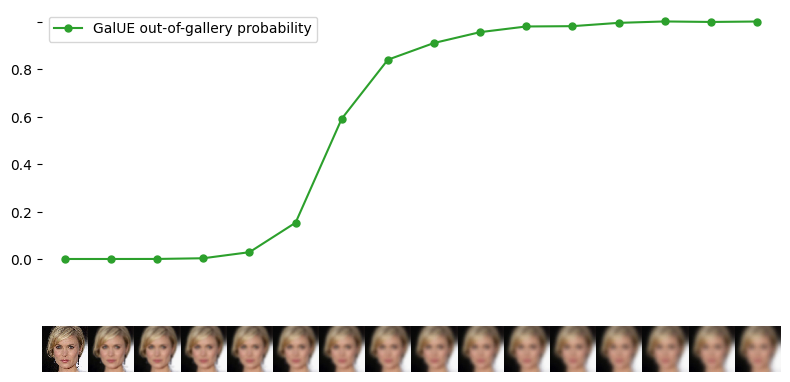

In [52]:
T_galue = 10  # 0.28836 #5
gallery_kappa = 50
T_holue = 5
kappa_galue = 200
id_to_color = {0: "black", 1: "green", 2: "cyan"}
ids = [0, 1, 2]  # [0] #[0, 1, 2]
estimator = PosteriorProb(kappa=kappa_galue, beta=0.5, class_model="vMF", K=2)
for test_id in ids:
    fig, axs = plt.subplots(2, 1, sharex=True, figsize=(8, 5), frameon=False)
    fig.subplots_adjust(hspace=0, bottom=0, wspace=0)
    first_gallery_emb = id_to_gallery_emb[test_id][0]
    second_gallery_emb = id_to_gallery_emb[test_id][1]
    gallery_embeddings = np.concatenate([first_gallery_emb, second_gallery_emb])
    probe_embeddings = []
    for j in np.arange(0, nose_iteration_size + 1):
        probe_embeddings.append(id_to_probe_emb[test_id][j])
    probe_embeddings = np.array(probe_embeddings)

    probe_embeddings = np.array(probe_embeddings)
    # compute similarity matrix
    similarity_matrix = probe_embeddings @ gallery_embeddings.T

    probabilities = torch.exp(
        estimator.compute_all_class_log_probabilities(
            torch.tensor(similarity_matrix), T=T_galue
        )
    ).numpy()
    gallery_unc = np.ones((2, 1))
    unc_holue = get_holue_unc(
        test_id,
        gallery_embeddings,
        gallery_unc,
        probe_embeddings,
        np.array(id_to_probe_unc[test_id]),
        num_images=nose_iteration_size,
        gallery_kappa=gallery_kappa,
        T=T_holue,
    )
    scale = 256
    shift = 256 / 2
    x = np.arange(nose_iteration_size + 1) * scale + shift
    galue_unc = (
        -np.max(probabilities, axis=1) + 1
    )  # (-np.max(probabilities, axis=1) + 1)
    data_unc = -np.array(np.exp(id_to_probe_unc[test_id]))
    data_unc = (data_unc - np.min(data_unc)) / (
        (np.max(data_unc) - np.min(data_unc)) * 2
    )
    axs[0].plot(
        x,
        galue_unc * scale,
        marker="o",
        markersize=5,
        label="GalUE",
        color="tab:green",
    )
    axs[0].plot(
        x,
        (unc_holue - unc_holue[0]) * scale,
        marker="o",
        markersize=5,
        label="HolUE",
        linestyle="--",
        color="tab:cyan",
    )
    axs[0].plot(
        x,
        data_unc * scale,
        marker="o",
        markersize=5,
        label="SCF",
        color="tab:orange",
        linestyle="dashdot",
    )
    axs[0].axis("off")
    axs[0].legend()

    blured_images = []
    for i in range(nose_iteration_size + 1):
        image_path = str(
            loose_crop_path
            / (str(test_id) + f"_{probe_image_index}_" + str(i).zfill(4) + ".jpg")
        )
        blured_images.append(plt.imread(image_path))
    # gallery images outline
    axs[1].imshow(np.concatenate(blured_images, axis=1), interpolation="none")
    axs[1].axis("off")
    fig.tight_layout()
    fig.savefig(
        f"/app/paper_assets/images/nose_{test_id}",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0,
    )
    fig_prob, axs_prob = plt.subplots(2, 1, sharex=True, figsize=(8, 5), frameon=False)
    axs_prob[0].plot(
        x,
        probabilities[:, -1] * scale,
        label="GalUE out-of-gallery probability",
        color="tab:green",
        marker="o",
        markersize=5,
    )
    axs_prob[0].set_yticklabels(
        np.around(np.array([-50, 0, 50, 100, 150, 200]) / 256, 1)
    )
    axs_prob[0].spines["top"].set_visible(False)
    axs_prob[0].spines["right"].set_visible(False)
    axs_prob[0].spines["bottom"].set_visible(False)
    axs_prob[0].set_xticks([])
    axs_prob[0].spines["left"].set_visible(False)
    axs_prob[0].legend()
    axs_prob[1].imshow(np.concatenate(blured_images, axis=1), interpolation="none")
    axs_prob[1].axis("off")
    fig_prob.tight_layout()
    fig_prob.savefig(
        f"/app/paper_assets/images/nose_{test_id}_prob",
        dpi=300,
        bbox_inches="tight",
        pad_inches=0,
    )

In [48]:
data_unc

array([0.        , 0.20944704, 0.3823045 , 0.4466549 , 0.47808036,
       0.49009806, 0.5       , 0.49400592, 0.48961377, 0.47546133,
       0.4681775 , 0.4457655 , 0.4516626 , 0.44363293, 0.4574202 ,
       0.46988598], dtype=float32)

In [46]:
galue_unc

array([-1.        , -0.9999924 , -0.9998398 , -0.9971735 , -0.9727224 ,
       -0.93371814, -0.8151308 , -0.5581061 , -0.56472796, -0.7828398 ,
       -0.84346044, -0.88392544, -0.8962848 , -0.9148135 , -0.9105868 ,
       -0.9118242 ], dtype=float32)